# DATASCI 503, Homework 7: Ensemble Methods and Decision Trees

This assignment covers classification trees, random forests, and gradient boosting classifiers.

---

**Problem 1 (ISLP Ch 8, Exercise 5):** Majority Vote vs Average Probability

Suppose we produce ten bootstrapped samples from a data set containing red and green classes. We then apply a classification tree to each bootstrapped sample and, for a specific value of X, produce 10 estimates of P(Class is Red|X): 0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, and 0.75.

There are two common ways to combine these results together into a single class prediction. One is the majority vote approach discussed in this chapter. The second approach is to classify based on the average probability. In this example, what is the final classification under each of these two approaches?

Approach 1:

p(c = red | x) = 0.1, p(c = green | x) = 1 - 0.1 = 0.9. Green wins

p(c = red | x) = 0.15, p(c = green | x) = 1 - 0.15 = 0.85. Green wins

p(c = red | x) = 0.2, p(c = green | x) = 1 - 0.2 = 0.8. Green wins

p(c = red | x) = 0.2, p(c = green | x) = 1 - 0.2 = 0.8. Green wins

p(c = red | x) = 0.55, p(c = green | x) = 1 - 0.55 = 0.45. Red wins

p(c = red | x) = 0.6, p(c = green | x) = 1 - 0.6 = 0.4. Red wins

p(c = red | x) = 0.6, p(c = green | x) = 1 - 0.6 = 0.4. Red wins

p(c = red | x) = 0.65, p(c = green | x) = 1 - 0.65 = 0.35. Red wins

p(c = red | x) = 0.7, p(c = green | x) = 1 - 0.7 = 0.3. Red wins

p(c = red | x) = 0.75, p(c = green | x) = 1 - 0.75 = 0.25. Red wins

There are 6 Red and 4 green, therefore by majority vote the class will be RED.

Approach 2: 

p(c = red | x) =  (0.1 + 0.15 + 0.2 + 0.2 + 0.55 + 0.6 + 0.6 + 0.65 +  0.7 + 0.75)/ 10 = 0.45
            p(c = green | x ) = 1 - 0.45 = 0.55

By average probability, the class will be GREEN.

---

**Problem 2:** Gradient Boosting with Decision Stumps

Consider using gradient boosting to solve a regression problem. Assume that at each iteration, we fit the residuals using a "decision stump": a decision tree with exactly two leaf nodes. In this case, the final estimate of the regression function can be expressed in the form:

$$\hat{f}(X) = \sum_{j=1}^{p} \hat{f}_j(X_j)$$

**Question:** Explain why this is the case.

The boosted model from class slide:

$\hat{f}(X) = \sum_{b=1}^{B} \lambda \, \hat{f}^b(X)$

A stump has only two leaf nodes, so it splits on exactly one feature. This means stump $b$ depends only on a single variable $X_{j_b}$, so $\hat{f}^b(X) = \hat{f}^b(X_{j_b})$:

$\hat{f}(X) = \sum_{b=1}^{B} \lambda \, \hat{f}^b(X_{j_b})$

Since each term in this sum depends on only one variable, we can group the $B$ stumps by which variable they split on. Let $S_j \subseteq \{1, \dots, B\}$ be the subset of stumps that split on $X_j$. Every stump belongs to exactly one group, so:

$\hat{f}(X) = \sum_{j=1}^{p} \sum_{b \in S_j} \lambda \, \hat{f}^b(X_j)$

Define $\hat{f}_j(X_j) = \sum_{b \in S_j} \lambda \, \hat{f}^b(X_j)$, which is a function of $X_j$ alone. Then:

$\hat{f}(X) = \sum_{j=1}^{p} \hat{f}_j(X_j)$

This is an **additive model** — a sum of univariate functions with no interactions.

---

**Problem 3:** Classification Tree Sketches

Create a sketch that illustrates the connection between a decision
tree and the partition of input space that is implied by that decision tree. You
can do this on paper (and scan it) or use a drawing program.

(a) Draw an example partition of a two-dimensional feature space that could
result from a tree with binary splits, with each feature defined on the
interval [−1, 1]. Include at least 5 regions

Answer: part_a_partition.png

![part_a_partition.png](part_a_partition.png)

(b) Draw a decision tree corresponding to the partition you drew, labeling
every tree branch. Show terminal nodes as rectangles and interior nodes
as circles. Do not include predictions at the terminal nodes, just the
branch labels (e.g. $X_1 < 0.5$).

Answer: part_b_tree.png

![part_b_tree.png](part_b_tree.png)


(c) Draw the path of a particular point, with $X_1 = X_2 = 0.5$, through your
tree and label the terminal node where it ends up. Mark this point in
your plot from part (a) as well.

Answer: part_c_path.png

![part_c_path.png](part_c_path.png)


## Crab Species Classification

The following problems use the crabs dataset, which contains five size-related measurements of two different species of crabs (blue and orange). There are 50 male and 50 female crabs of each species. We will classify species based on the predictor variables and evaluate errors using the misclassification rate.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

---

**Problem 4:** Train-Test Split

Load the crabs dataset and perform a train-test split with the following specifications:
- Random state: 6789
- Training set size: 80% of the dataset
- Stratify the split according to both species and sex

This stratification ensures that approximately the same proportions of species/sex combinations appear in both the training and test datasets.

Store the results in `X_train`, `X_test`, `y_train`, and `y_test`. The features should include the five numerical measurements and sex (encoded as 0 for Female, 1 for Male). The target should be the species column.

In [4]:
# Load the crabs dataset
crabs = pd.read_csv("data/crabs.csv", index_col=[0])

X = crabs.drop(columns=["sp", "index"])

X['sex'] = (X['sex'] == 'M').astype(int)

y = np.array(crabs["sp"]).reshape(-1, 1)

stratify = crabs["sp"] + "_" + crabs["sex"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6789, stratify=stratify)

FileNotFoundError: [Errno 2] No such file or directory: 'data/crabs.csv'

In [4]:
crabs.columns

Index(['sp', 'sex', 'index', 'FL', 'RW', 'CL', 'CW', 'BD'], dtype='str')

In [5]:
# Test assertions
assert X_train.shape == (160, 6), f"X_train should have shape (160, 6), got {X_train.shape}"
assert X_test.shape == (40, 6), f"X_test should have shape (40, 6), got {X_test.shape}"
assert y_train.shape == (160, 1), f"y_train should have shape (160, 1), got {y_train.shape}"
assert y_test.shape == (40, 1), f"y_test should have shape (40, 1), got {y_test.shape}"
print("All tests passed!")

All tests passed!


---

**Problem 5:** Decision Tree Classifier

Train a classification tree to predict species from the five numerical measurements and sex. 

**(a)** Use cross-validation (5 folds) to select the optimal `max_leaf_nodes` from the values {2, 3, ..., 10}.

In [ ]:
# your code here
from sklearn.model_selection import cross_val_score

max_leaf_range = range(2, 11)
best_score = 0
best_max_leaf_nodes = 2

for i in max_leaf_range:
    dt = DecisionTreeClassifier(random_state=6789, max_leaf_nodes=i)
    val_score = cross_val_score(dt, X_train, y_train, cv=5).mean()
    if val_score > best_score:
        best_score = val_score
        best_max_leaf_nodes = i

tree_clf = DecisionTreeClassifier(random_state=6789, max_leaf_nodes=best_max_leaf_nodes).fit(X_train, y_train)

In [7]:
# Test assertions
assert hasattr(tree_clf, "predict"), "tree_clf should be a fitted classifier"
assert tree_clf.max_leaf_nodes is not None, "tree_clf should have max_leaf_nodes set"
assert 2 <= tree_clf.max_leaf_nodes <= 10, "max_leaf_nodes should be between 2 and 10"
print("All tests passed!")

All tests passed!


**(b)** Plot the tree and comment on which variables are used.

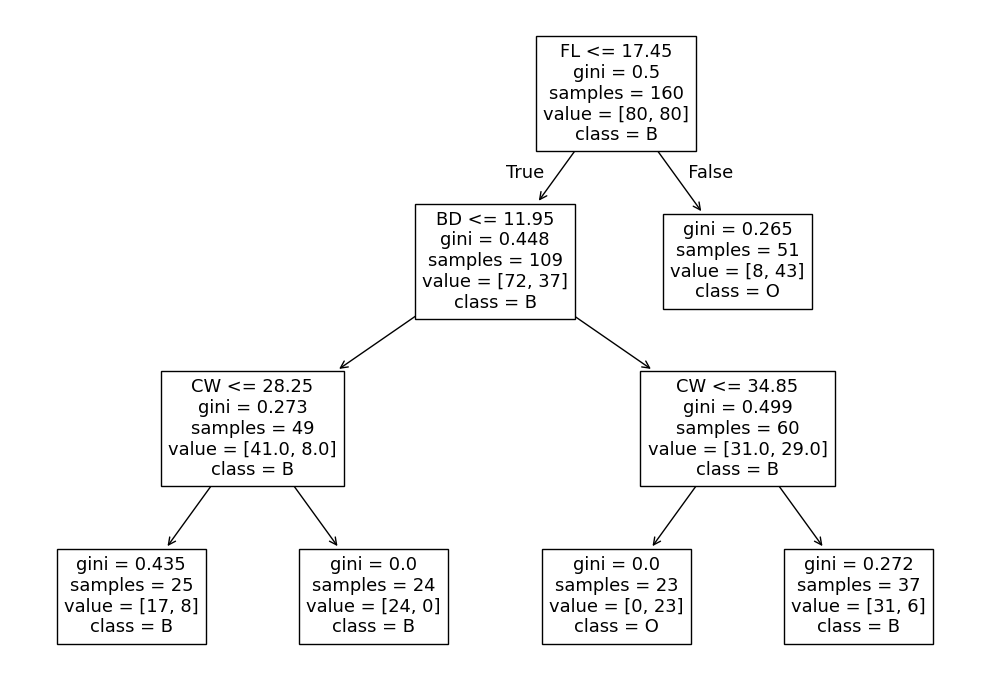

In [8]:
# your code here
plt.figure(figsize=(10, 7))
plot_tree(tree_clf, feature_names=X.columns.tolist(), class_names=["B", "O"])
plt.tight_layout()
plt.show()

In [9]:
# Test assertions
assert hasattr(tree_clf, "tree_"), "tree_clf should be a fitted decision tree"
assert tree_clf.n_features_in_ == 6, "Tree should be trained on 6 features"
print("All tests passed!")

All tests passed!




> Variable used are FL, BD and CW.

**(c)** Compute and report training and test errors.

Store the best tree in a variable called `tree_clf`.

In [10]:
# your code here

train_accuracy = tree_clf.score(X_train, y_train)
train_error = 1 - train_accuracy
print(f"Training error: {train_error:.4f}")

test_accuracy = tree_clf.score(X_test, y_test)
test_error = 1 - test_accuracy
print(f"Test error:     {test_error:.4f}")

Training error: 0.1375
Test error:     0.3250


---

**Problem 6:** Random Forest Classifier

Train a random forest with the following specifications:
- Use m=5 randomly selected predictors for each split (`max_features=5`)
- Use 1000 trees (`n_estimators=1000`)

Store the random forest classifier in a variable called `rf_clf`.

**(a)** Make a variable importance plot.

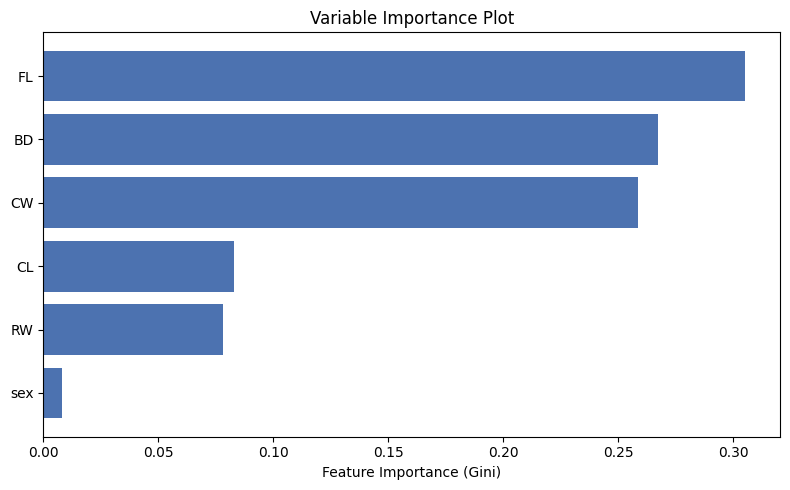

In [11]:
rf_clf = RandomForestClassifier(n_estimators=1000, max_features=5, random_state=6789)
rf_clf.fit(X_train, y_train.ravel())

variable_importances = rf_clf.feature_importances_
feature_names = X.columns.tolist()
sorted_idx = np.argsort(variable_importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(sorted_idx)), variable_importances[sorted_idx], color="#4C72B0")
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Feature Importance (Gini)")
plt.title("Variable Importance Plot")
plt.tight_layout()
plt.show()

In [12]:
# Test assertions
assert hasattr(rf_clf, "predict"), "rf_clf should be a fitted classifier"
assert rf_clf.n_estimators == 1000, "Random forest should have 1000 trees"
assert rf_clf.max_features == 5, "max_features should be 5"
print("All tests passed!")

All tests passed!


**(b)** Compare the variable importance with your results from the single decision tree.



> The variable importance result agrees with the single decsion tree that the most useful variables are FL, BD and CW.

**(c)** Compute training and test errors.

In [13]:
# your code here
rf_train_acc = rf_clf.score(X_train, y_train.ravel())
rf_test_acc = rf_clf.score(X_test, y_test.ravel())

rf_train_err = 1 - rf_train_acc
rf_test_err = 1 - rf_test_acc

print(f"Training error: {rf_train_err:.4f}")
print(f"Test error:     {rf_test_err:.4f}")


Training error: 0.0000
Test error:     0.2500


In [14]:
# Test assertions
rf_train_acc = rf_clf.score(X_train, y_train)
rf_test_acc = rf_clf.score(X_test, y_test)
assert rf_train_acc > 0.8, f"RF training accuracy should be above 80%, got {rf_train_acc}"
assert rf_test_acc > 0.7, f"RF test accuracy should be above 70%, got {rf_test_acc}"
print("All tests passed!")

All tests passed!


---

**Problem 7:** Gradient Boosting Classifier

Fit a `HistGradientBoostingClassifier` to the data. Store the histogram gradient boosting classifier (with `max_iter=1000`) in a variable called `hgb_clf`.

**(a)** Plot the training and test errors as a function of the number of trees M, for M from 1 to 1000.

**Hint:** Fit the classifier once with `max_iter=1000`, then use `staged_predict` to calculate the error at each iteration.

In [15]:
# your code here

hgb_clf = HistGradientBoostingClassifier(max_iter=1000, random_state=42)
hgb_clf.fit(X_train, y_train.ravel())

train_scores = []
test_scores = []
train_errors = []
test_errors = []

for i, (y_train_pred, y_test_pred) in enumerate(zip(hgb_clf.staged_predict(X_train), hgb_clf.staged_predict(X_test))):
    train_acc = accuracy_score(y_train.ravel(), y_train_pred)
    test_acc = accuracy_score(y_test.ravel(), y_test_pred)
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    train_errors.append(1 - train_acc)
    test_errors.append(1 - test_acc)

In [16]:
# Test assertions
assert hasattr(hgb_clf, "predict"), "hgb_clf should be a fitted classifier"
assert hgb_clf.max_iter == 1000, "max_iter should be 1000"
assert len(train_scores) == 1000, "Should have 1000 training scores"
assert len(test_scores) == 1000, "Should have 1000 test scores"
print("All tests passed!")

All tests passed!


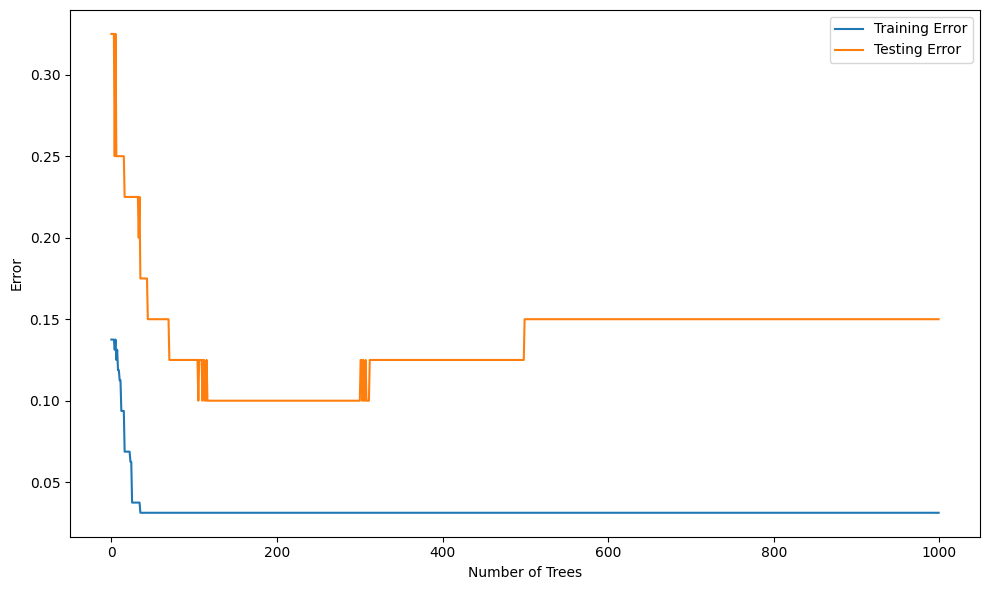

In [17]:
# Plot error curves
plt.figure(figsize=(10, 6))
plt.plot(train_errors, label="Training Error")
plt.plot(test_errors, label="Testing Error")
plt.xlabel("Number of Trees")
plt.ylabel("Error")
plt.legend()
plt.tight_layout()
plt.show()

**(b)** Choose an optimal value of M and justify your choice.

In [18]:
optimal_m = np.argmin(test_errors) + 1  
print(optimal_m)

106



> Optimal M (106) is chosen based on the number of of trees that minimises the test error. This exist between 100 and 250 in the plotted figure.  

> In order to save computational cost of training more trees the earliest (the first number of trees to archieve this error) is selected. 

> That is, it is pointless to train 250 trees when 106 can give the same results.

**(c)** Report training and test errors for your chosen M.

In [19]:
# your code here
print(f"Training error: {train_errors[optimal_m-1]:.4f}")
print(f"Test error:     {test_errors[optimal_m-1]:.4f}")

Training error: 0.0312
Test error:     0.1000


---

**Problem 8:** Method Comparison

Comment on which method appears to perform best for this dataset and whether the results (training and test errors) are consistent across methods.

> The HistGradientBoostingClassifier performed the best having the lowest test error (10%), followed by the RandomForestClassifier (25%) 

> and the worst being DecisionTreeClassifier with 32.5% test error. 

> Although, the RandomForestClassifier has the lowest training error (0%), while HistGradientBoostingClassifier and DecisionTreeClassifier are 3% and 13.75%, 

> we focus on the lowest test error to avoid overfitting.

> The errors (training and test) are not consistent across all methods.